# Clustering & quality filtering

`AnalysisPipeline.filter_and_cluster` does two things in one call:

1. **Quality filtering** (`FilteringCriteria`) — drops localisations with poorly-constrained
   fits: high `chi_sqr`, large position/colour/sigma uncertainties, too few photons.
2. **Clustering** (`ClusteringConfig`) — groups repeat localisations of the same physical
   molecule (HDBSCAN by default) into a single averaged row.

Data: `test_tiffs/clustering/` — a **PAINT**-style fixture (continuous transient probe
rebinding, no bleaching): 15 candidates, mean ~59 on-frames each over 400 frames. This is
the opposite blinking regime from `01_getting_started_smlm_fitting.ipynb`'s STORM fixture
(bleaches after a handful of cycles) — here the *default* `ClusteringConfig(min_cluster_size=10)`
is exactly right, since real molecules genuinely reappear far more than 10 times.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt

from pyS3M.AnalysisPipeline import AnalysisPipeline, FittingConfig
from pyS3M.Constants import AnalysisConfig, FilteringCriteria
from pyS3M.clustering import ClusteringConfig
import pyS3M.PlottingBase as PlottingBase

REPO_ROOT = Path.cwd().resolve().parents[1]
DATA_DIR = REPO_ROOT / "test_tiffs" / "clustering"
CALIBRATION_DIR = REPO_ROOT / "Camera_Calibrations" / "Ximea_Camera"

cfg = AnalysisConfig(display=False)
pipe = AnalysisPipeline(camera="ximea", config=cfg)
pipe.load_calibration(CALIBRATION_DIR)
plotter = PlottingBase.PublicationPlotter()

fc = FittingConfig(peak_wavelength=0.685, pfa=1e-3)
pipe.fit(DATA_DIR, mode="smlm", fitting_config=fc)

locs = pipe.load_localisations(DATA_DIR)
print(f"{len(locs)} raw localisations")

Detecting puncta:   0%|          | 0/400 [00:00<?, ?it/s]

1006 raw localisations


## Default filter + cluster

`FilteringCriteria()`/`ClusteringConfig()` with no arguments use the package defaults —
these are the same defaults the GUI's Post-Processing panel starts with.

In [2]:
sm_db, sf_db = pipe.filter_and_cluster(locs)
print(f"{len(sm_db)} molecules from {len(sf_db)} quality-filtered localisations "
      f"(default min_cluster_size={ClusteringConfig().min_cluster_size})")

16 molecules from 437 quality-filtered localisations (default min_cluster_size=10)


## What each `FilteringCriteria` threshold actually does

`sf_db` still has every quality metric column, so we can see which criterion is doing the
most work for this fixture.

In [3]:
print("photons:        ", sf_db["photons"].describe()[["mean", "min", "max"]].to_dict())
print("xc_err (px):    ", sf_db["xc_err"].describe()[["mean", "min", "max"]].to_dict())
print("chi_sqr:        ", sf_db["chi_sqr"].describe()[["mean", "min", "max"]].to_dict())
print()
print(f"FilteringCriteria() defaults: {FilteringCriteria()}")

photons:         {'mean': 5728.03955078125, 'min': 876.974853515625, 'max': 10310.3984375}
xc_err (px):     {'mean': 0.05809536203742027, 'min': 0.03379727154970169, 'max': 0.1754201352596283}
chi_sqr:         {'mean': 1.5178749561309814, 'min': 1.2465089559555054, 'max': 1.6424355506896973}

FilteringCriteria() defaults: FilteringCriteria(chi_val=None, max_localisation_error=1.0, max_colour_error=0.15, min_sigma=None, max_sigma=None, max_sigma_error=None, min_photons=500, max_photons=None)


## Effect of `min_cluster_size`

Since this fixture's molecules blink ~59 times on average, `min_cluster_size` can range
fairly widely before it starts rejecting genuine molecules — but push it past the *typical*
blink count and real molecules start getting discarded as noise.

In [4]:
for mcs in [2, 10, 40, 80]:
    cc = ClusteringConfig(min_cluster_size=mcs)
    sm_i, sf_i = pipe.filter_and_cluster(locs, clustering_config=cc)
    print(f"min_cluster_size={mcs:>3d}: {len(sm_i):>3d} molecules from {len(sf_i):>5d} localisations")

min_cluster_size=  2:  18 molecules from   437 localisations
min_cluster_size= 10:  16 molecules from   437 localisations
min_cluster_size= 40:   6 molecules from   411 localisations
min_cluster_size= 80:   2 molecules from   249 localisations


## Render — molecule positions, coloured by photon count

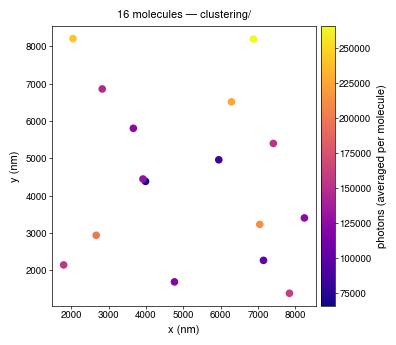

In [5]:
pixel_size_nm = pipe.pixel_size * 1000.0
fig, ax = plotter.create_figure()
# scatter_plot has no continuous-colormap option -- colour-by-photon-count stays direct
# matplotlib; add_colorbar still standardises the colorbar itself.
sc = ax.scatter(sm_db["xc"] * pixel_size_nm, sm_db["yc"] * pixel_size_nm,
                 c=sm_db["photons"], cmap="plasma", s=20)
ax.set_aspect("equal")
ax.set_xlabel("x (nm)")
ax.set_ylabel("y (nm)")
ax.set_title(f"{len(sm_db)} molecules — clustering/")
plotter.add_colorbar(sc, ax, label="photons (averaged per molecule)")
plt.show()

## Next: `05_channel_unmixing.ipynb`